In [ ]:
import yfinance
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import requests
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
import plotly.express as px



In [163]:
os.makedirs("Data", exist_ok=True)

In [164]:
btc = yfinance.Ticker("BTC-USD")
btc = btc.history(period="max")
btc = btc.reset_index(level=0)
btc.to_csv("Data/btc.csv", index=False)
btc

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,0.0,0.0
1,2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,0.0,0.0
2,2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,0.0,0.0
3,2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,0.0,0.0
4,2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,0.0,0.0
...,...,...,...,...,...,...,...,...
3857,2025-04-09 00:00:00+00:00,76273.562500,83541.000000,74589.671875,82573.953125,84213627038,0.0,0.0
3858,2025-04-10 00:00:00+00:00,82565.976562,82700.929688,78456.132812,79626.140625,44718000633,0.0,0.0
3859,2025-04-11 00:00:00+00:00,79625.046875,84247.476562,78936.320312,83404.835938,41656778779,0.0,0.0
3860,2025-04-12 00:00:00+00:00,83404.515625,85856.187500,82769.375000,85287.109375,24258059104,0.0,0.0


In [165]:
df = pd.read_csv("Data/btc.csv")
df_a = pd.read_csv("Data/Articles/article_result.csv")

In [166]:
df = df.drop(columns=["Dividends", "Stock Splits"])

In [167]:
df["Date"] = pd.to_datetime(df["Date"], utc=True)
df["Date"] = df["Date"].dt.date
df

,Date,Open,High,Low,Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100
...,...,...,...,...,...,...
3857,2025-04-09,76273.562500,83541.000000,74589.671875,82573.953125,84213627038
3858,2025-04-10,82565.976562,82700.929688,78456.132812,79626.140625,44718000633
3859,2025-04-11,79625.046875,84247.476562,78936.320312,83404.835938,41656778779
3860,2025-04-12,83404.515625,85856.187500,82769.375000,85287.109375,24258059104


In [168]:
df["Close"] = df["Close"].shift(-1)
df = df[:-1]
df = df.reset_index(drop=True)

In [169]:
print("Number of mismatches/gaps in Date: ",len(pd.date_range(start=df["Date"].min(), end=df["Date"].max()).difference(df["Date"])))
print("Number of nulls in the Dataset: ", df.isnull().sum().sum())

Number of mismatches/gaps in Date:  0
Number of nulls in the Dataset:  0


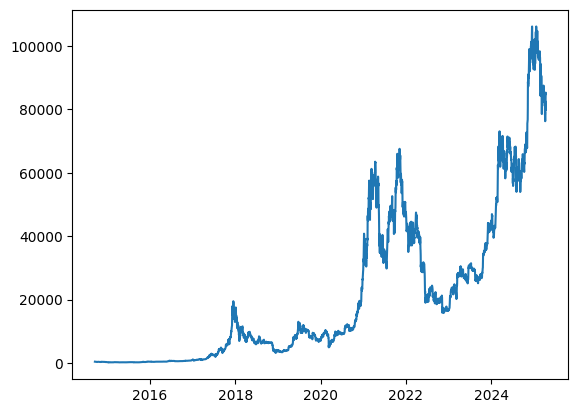

In [170]:
plt.plot(df["Date"], df["Close"])

In [171]:
def calculate_rsi(df: pd.DataFrame, period: int = 14, target_col_name: str = "Close"):
    # calculates RSI for x days period and adds it to a dataframe
    # default period is 14 days.
    # Used formula: https://chartschool.stockcharts.com/table-of-contents/technical-indicators-and-overlays/technical-indicators/relative-strength-index-rsi
    df = df.copy()

    df["change"] = df[target_col_name].diff() # creates column of close price change from previous days

    df["gain"] = df["change"].apply(lambda x: x if x > 0 or pd.isna(x) else 0) # if price change is positive, the price change is written in gain column, otherwise is 0
    df["loss"] = df["change"].apply(lambda x: abs(x) if x < 0 or pd.isna(x) else 0) #if price change is negative, the price change(in absolute) is written in gain column, otherwise is 0

    df[f"avg_up_{period}"] = df["gain"].rolling(period).mean() # calculating x days moving average of gains
    df[f"avg_down_{period}"] = df["loss"].rolling(period).mean() # calculating x days moving average of losses


    for i in range(period + 1, len(df)):
        df.loc[i, f"avg_up_{period}"] = (df.loc[i - 1, f"avg_up_{period}"] * 13 + df.loc[i, "gain"])/14  # 2nd smoothing stage of RSI
        df.loc[i, f"avg_down_{period}"] = (df.loc[i - 1, f"avg_down_{period}"] * 13 + df.loc[i, "loss"])/14 # 2nd smoothing stage of RSI


    df["RSI"] = 100 - (100/(1+(df[f"avg_up_{period}"] / df[f"avg_down_{period}"]))) # calculates RSI with no smoothing

    df = df.drop(columns=["change", "gain", "loss", f"avg_up_{period}", f"avg_down_{period}"])

    return df

def calculate_roc(df: pd.DataFrame, periods = [1, 7, 14], target_col_name: str = "Close"):
    # Calculates Rate of Change (ROC) for chosen periods (percentage difference of closing price vs previous closing price)
    # adds the result to the dataframe
    # https://www.investopedia.com/terms/p/pricerateofchange.asp
    df = df.copy()

    if type(periods) == int:
        df[f"ROC_{periods}"] = df[target_col_name].pct_change(periods) * 100
    elif type(periods) == list:
        for period in periods:
            df[f"ROC_{period}"] = df[target_col_name].pct_change(period) * 100
    
    return df

def calculate_mov_avg(df: pd.DataFrame, periods = 14, target_col_name: str = "Close"):
    # calculates x days moving average
    df = df.copy()

    if type(periods) == int:
        df[f"MOV_AVG_{periods}"] = df[target_col_name].rolling(periods).mean()
    elif type(periods) == list:
        for period in periods:
            df[f"MOV_AVG_{period}"] = df[target_col_name].rolling(period).mean()
    
    return df

def calculate_mov_sd(df: pd.DataFrame, periods = 14, target_col_name: str = "Close"):
    # calculates x days moving standard deviation
    df = df.copy()

    if type(periods) == int:
        df[f"MOV_SD_{periods}"] = df[target_col_name].rolling(periods).std()
    elif type(periods) == list:
        for period in periods:
            df[f"MOV_SD_{period}"] = df[target_col_name].rolling(period).std()
        
    return df

def calculate_vwap(df: pd.DataFrame):
    df = df.copy()
    try:
        df["VWAP"] = (df["Volume"] * ((df["Close"] + df ["High"] + df["Low"])/3)).cumsum()/df["Volume"].cumsum()
    except KeyError:
        print("The required columns for the calculation with exact names: [Volume, Low, High, Close]")
        return
    
    return df

def get_past_close(df: pd.DataFrame, periods = [1, 7, 14], target_col_name: str = "Close"):

    df = df.copy()

    if type(periods) == int:
        df[f"Close_t-{periods}"] = df[target_col_name].shift(periods)
    elif type(periods) == list:
        for period in periods:
            df[f"Close_t-{period}"] = df[target_col_name].shift(period)

    return df


def get_articles_info(df: pd.DataFrame, df_articles: pd.DataFrame):
    # calculates score in articles dataframe by multiplication of Sentiment and Relevance columns, join to the original dataset on column Date
    # The score of the article is filled to maximum 7 next days
    # Added flag column to indicate whether the article score is available for the particular day
    df = df.copy()
    df_a = df_articles.copy()

    df_a["News_Score"] = df_a["Sentiment"] * df_a["Relevance"]
    df_a = df_a[["Date", "News_Score"]]
    df_a = df_a.groupby("Date").agg("mean").reset_index()
    df_a["Date"] = pd.to_datetime(df_a["Date"]).dt.date
    df = pd.merge(df, df_a, how="left", on="Date")
    df["News_Score"] = df["News_Score"].ffill(limit=7)
    df["News_Available"] = df["News_Score"].apply(lambda x: 1 if pd.notna(x) else 0)
    df["News_Score"] = df["News_Score"].fillna(0)

    return df

def get_fear_index(df: pd.DataFrame, delete_rows_without_index: bool = True):
    # Data obtained with api on https://alternative.me/crypto/fear-and-greed-index/
    df = df.copy()

    try:
        response = requests.get("https://api.alternative.me/fng/?limit=0")
    except:
        print("An error occured extracting fear index.")
        return
    
    if response.status_code != 200:
        print("An error occured extracting fear index.")
        return
    else:
        src = response.json()["data"]

        data = {"Fear_Index":[], "timestamp":[]}
        for row in src:
            data["Fear_Index"].append(row.get("value", None))
            data["timestamp"].append(row.get("timestamp", None))

        data = pd.DataFrame(data)
        data["timestamp"] = data["timestamp"].astype(int)
        data["Fear_Index"] = data["Fear_Index"].astype(int)
        data["timestamp"] = pd.to_datetime(data["timestamp"], unit="s").dt.date

        if delete_rows_without_index:
            df = pd.merge(df, data, how="inner", left_on="Date", right_on="timestamp")
            df = df.drop(columns=["timestamp"])
        else:
            df = pd.merge(df, data, how="left", left_on="Date", right_on="timestamp")
            df = df.drop(columns=["timestamp"])
            df["Fear_Index_Available"] = df["Fear_Index"].apply(lambda x: 1 if pd.notna(x) else 0)
            df["Fear_Index"] = df["Fear_Index"].fillna(50)

        return df


In [172]:
def transform_dataset(df: pd.DataFrame, df_article: pd.DataFrame, target_col_name: str = "Close", day_col_name: str = "Day_Of_Week", rsi_period: int = 14, roc_periods = [1, 7, 14]
                      ,mov_avg_period: int = 14, mov_sd_period: int = 14, past_target_periods = [1, 7, 14], delete_rows_without_index: bool = True, save_csv: bool = False):
    df = df.copy()
    df_a = df_article.copy()

    df = calculate_rsi(df, rsi_period, target_col_name)
    df = calculate_roc(df, roc_periods, target_col_name)
    df = calculate_vwap(df)
    df = calculate_mov_avg(df, mov_avg_period, target_col_name)
    df = calculate_mov_sd(df, mov_sd_period, target_col_name)
    df = get_past_close(df, past_target_periods, target_col_name)
    df = get_articles_info(df, df_a)
    df = get_fear_index(df, delete_rows_without_index)

    df = df.dropna()

    if save_csv:
        df.to_csv("Data/transformed_data.csv", index=False)
    
    return df

In [173]:
def direction_accuracy(y_true, y_pred):
    # Calculates direction_accuracy
    # Total of correct price move (predicted increase or decrease) / total price moves

    actual_direction = np.sign(np.diff(y_true)) 
    predicted_direction = np.sign(np.diff(y_pred))  

    correct_directions = (actual_direction == predicted_direction).sum()
    total_comparisons = len(actual_direction)

    return correct_directions / total_comparisons if total_comparisons > 0 else np.nan

In [174]:
df = transform_dataset(df, df_a, save_csv=False, delete_rows_without_index=False, mov_avg_period=[3, 7, 14], past_target_periods=[1, 2, 3, 5])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3847 entries, 14 to 3860
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  3847 non-null   object 
 1   Open                  3847 non-null   float64
 2   High                  3847 non-null   float64
 3   Low                   3847 non-null   float64
 4   Close                 3847 non-null   float64
 5   Volume                3847 non-null   int64  
 6   RSI                   3847 non-null   float64
 7   ROC_1                 3847 non-null   float64
 8   ROC_7                 3847 non-null   float64
 9   ROC_14                3847 non-null   float64
 10  VWAP                  3847 non-null   float64
 11  MOV_AVG_3             3847 non-null   float64
 12  MOV_AVG_7             3847 non-null   float64
 13  MOV_AVG_14            3847 non-null   float64
 14  MOV_SD_14             3847 non-null   float64
 15  Close_t-1             384

<Axes: >

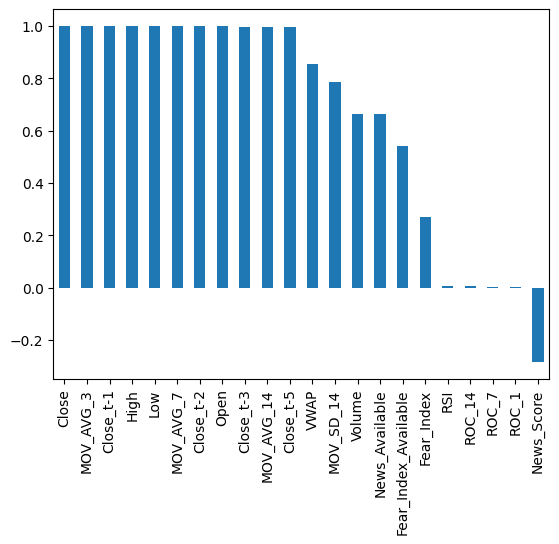

In [175]:
corr = df.corr(numeric_only=True)["Close"].sort_values(ascending=False)
corr.plot.bar()

In [176]:
df = df.set_index("Date")
target = df["Close"].to_frame()
features = df.drop(columns=["Close"])
f_scaler = MinMaxScaler()
t_scaler = MinMaxScaler()


In [177]:
# Parameters
test_ratio = 0.85
window_size = 50

In [178]:
df_x_train = features.iloc[:int(len(df)*test_ratio),]
df_x_test = features.iloc[int(len(df)*test_ratio):,]
df_y_train = target[:int(len(df)*test_ratio)]
df_y_test = target[int(len(df)*test_ratio):]

In [179]:
df_x_train.shape

(3269, 21)

In [180]:
df_x_train.head(10)

,Open,High,Low,Volume,RSI,ROC_1,ROC_7,ROC_14,VWAP,MOV_AVG_3,...,MOV_AVG_14,MOV_SD_14,Close_t-1,Close_t-2,Close_t-3,Close_t-5,News_Score,News_Available,Fear_Index,Fear_Index_Available
Date,,,,,,,,,,,,,,,,,,,,,
2014-10-01,387.427002,391.378998,380.779999,26229400,35.852649,-2.226972,-8.868882,-11.631329,405.669896,381.876994,...,398.390496,18.043237,383.614990,386.944000,375.467010,399.519989,0.0,0,50.0,0
2014-10-02,383.988007,385.497009,372.946014,21777700,32.711067,-4.148536,-11.105395,-8.937273,404.102933,372.732992,...,395.870211,20.832576,375.071991,383.614990,386.944000,377.181000,0.0,0,50.0,0
2014-10-03,375.181000,377.695007,357.859009,30901200,27.584355,-8.524332,-17.684720,-19.573787,400.992792,354.483327,...,390.153211,27.038518,359.511993,375.071991,383.614990,375.467010,0.0,0,50.0,0
2014-10-04,359.891998,364.487000,325.885986,47236500,26.370756,-2.540849,-15.024879,-19.635626,395.360590,336.296000,...,384.559568,32.629694,328.865997,359.511993,375.071991,386.944000,0.0,0,50.0,0
2014-10-05,328.915985,341.800995,289.295990,83308096,30.160147,2.985554,-12.088412,-17.921830,385.292640,326.485006,...,379.411497,35.223091,320.510010,328.865997,359.511993,383.614990,0.0,0,50.0,0
2014-10-06,320.389008,345.134003,302.559998,79011800,32.546532,1.850467,-13.117399,-22.855905,378.815259,328.925344,...,372.296927,32.944861,330.079010,320.510010,328.865997,375.071991,0.0,0,50.0,0
2014-10-07,330.584015,339.247009,320.481995,49199900,38.730401,4.983236,-7.996295,-16.603061,376.103420,339.735341,...,367.278000,29.794340,336.187012,330.079010,320.510010,359.511993,0.0,0,50.0,0
2014-10-08,336.115997,354.364014,327.187988,54736300,42.804159,3.424378,-2.678416,-11.309753,374.246985,351.384338,...,363.953142,26.930545,352.940002,336.187012,330.079010,328.865997,0.0,0,50.0,0
2014-10-09,352.747986,382.726013,347.687012,83641104,41.943379,-0.948971,0.570223,-10.598498,373.279861,359.842672,...,360.891501,24.281714,365.026001,352.940002,336.187012,320.510010,0.0,0,50.0,0


In [181]:
df_x_test.shape

(578, 21)

In [182]:
df_x_test.head(10)

,Open,High,Low,Volume,RSI,ROC_1,ROC_7,ROC_14,VWAP,MOV_AVG_3,...,MOV_AVG_14,MOV_SD_14,Close_t-1,Close_t-2,Close_t-3,Close_t-5,News_Score,News_Available,Fear_Index,Fear_Index_Available
Date,,,,,,,,,,,,,,,,,,,,,
2023-09-13,25837.554688,26376.113281,25781.123047,13072077070,51.186651,1.187074,1.141297,2.345417,26870.643137,26200.447266,...,25901.605329,309.431881,26228.324219,25833.343750,25162.654297,25895.677734,0.048840,1,41.0,1
2023-09-14,26228.277344,26774.623047,26171.451172,13811359124,51.957909,0.260062,2.713844,3.131574,26870.553358,26458.897135,...,25959.317383,360.330210,26539.673828,26228.324219,25833.343750,25832.226562,0.048840,1,45.0,1
2023-09-15,26533.818359,26840.498047,26240.701172,11479735788,51.445364,-0.151876,2.597358,2.703962,26870.485454,26572.216146,...,26009.280413,393.757765,26608.693359,26539.673828,26228.324219,25162.654297,0.048840,1,45.0,1
2023-09-16,26606.199219,26754.769531,26473.890625,7402031417,50.988382,-0.128325,2.717385,2.174165,26870.446844,26570.387370,...,26049.610491,417.572319,26568.281250,26608.693359,26539.673828,25833.343750,0.048840,1,43.0,1
2023-09-17,26567.927734,26617.998047,26445.074219,6774210670,53.839043,0.829472,6.325354,3.648884,26870.413787,26618.916667,...,26116.886579,450.956333,26534.187500,26568.281250,26608.693359,26228.324219,0.048840,1,46.0,1
2023-09-18,26532.994141,27414.734375,26415.515625,15615339655,59.150031,1.707525,5.333314,5.551341,26870.455055,26833.195312,...,26219.110491,524.861960,26754.281250,26534.187500,26568.281250,26539.673828,0.048840,1,46.0,1
2023-09-19,26760.851562,27488.763672,26681.605469,13807690550,57.907555,-0.290724,3.445449,5.353779,26870.513663,27032.468750,...,26317.594169,558.968645,27211.117188,26754.281250,26534.187500,26608.693359,0.048840,1,46.0,1
2023-09-20,27210.228516,27379.505859,26864.082031,13281116604,49.860861,-2.080108,0.105348,1.247847,26870.529950,26970.252604,...,26340.982561,562.321275,27132.007812,27211.117188,26754.281250,26568.281250,-0.513445,1,47.0,1
2023-09-21,27129.839844,27152.939453,26389.300781,13371443708,50.019039,0.044925,-0.109457,2.601417,26870.489741,26759.736328,...,26389.119280,550.918134,26567.632812,27132.007812,27211.117188,26534.187500,-0.513445,1,47.0,1


In [183]:
x_train = f_scaler.fit_transform(df_x_train)
x_test = f_scaler.transform(df_x_test)
y_train = t_scaler.fit_transform(df_y_train)
y_test = t_scaler.transform(df_y_test)


In [184]:
def create_sequences(x, y, window):
    x_arr = []
    y_arr = []
    for i in range(len(x) - window):
        x_arr.append(x[i:i+window])
        y_arr.append(y[i+window])
    
    return np.array(x_arr), np.array(y_arr)

In [185]:
x_train, y_train = create_sequences(x_train, y_train, window_size)
x_test, y_test = create_sequences(x_test, y_test, window_size)

In [186]:
model = Sequential([
    LSTM(256, return_sequences=False),
    Dense(256, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_absolute_error")
history = model.fit(x_train, y_train, epochs=15, batch_size=16)



Epoch 1/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.0425
Epoch 2/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - loss: 0.0150
Epoch 3/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.0127
Epoch 4/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - loss: 0.0148
Epoch 5/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - loss: 0.0102
Epoch 6/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0102
Epoch 7/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - loss: 0.0095
Epoch 8/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 23s 107ms/step - loss: 0.0090
Epoch 9/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - loss: 0.0092
Epoch 10/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 0.0086
Epoch 11/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - loss: 0.0091
Epoch 12/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 36s 88ms/step - loss: 0.0083
Epoch 13/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0109
Epoch 14/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0078
Epoch 15/15
202/202 ━━━━━━━━━

In [187]:
y_pred = model.predict(x_test)
y_pred = t_scaler.inverse_transform(y_pred).flatten().tolist()
y_test = t_scaler.inverse_transform(y_test).flatten().tolist()

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [188]:
result_pred = df_y_test[window_size:].reset_index()
result_pred["Pred_Close"] = y_pred
result_pred = result_pred[["Date", "Pred_Close"]]
result_pred

,Date,Pred_Close
0,2023-11-02,35380.117188
1,2023-11-03,35275.121094
2,2023-11-04,35769.246094
3,2023-11-05,35916.148438
4,2023-11-06,35629.750000
...,...,...
523,2025-04-08,74538.078125
524,2025-04-09,80145.968750
525,2025-04-10,77680.523438
526,2025-04-11,79630.398438


In [189]:
df = df.reset_index()
result = pd.merge(df[["Date", "Close"]], result_pred, on="Date",  how="left")

In [190]:
plot_result = result.melt(id_vars="Date", var_name="True/Pred", value_name="Price")

In [191]:
fig = px.line(plot_result, x="Date", y="Price", color="True/Pred")
fig.show(config={"scrollZoom": True})

In [192]:
temp = result.loc[result["Pred_Close"].notna()]
previous_day_close = temp["Close"].shift(1)[1:]

print("Naive mean absolute percentage: ", mean_absolute_percentage_error(y_test[1:], previous_day_close)*100, "%")
print("Naive mean_absolute_error: ", mean_absolute_error(y_test[1:], previous_day_close))
print("Naive Direction accuracy: ", direction_accuracy(y_test[1:], previous_day_close), "%")

Naive mean absolute percentage:  1.9925904348273116 %
Naive mean_absolute_error:  1366.5313760080646
Naive Direction accuracy:  0.4695817490494297 %


In [193]:
print("R2: ", r2_score(y_test, y_pred))
print("mean absolute percentage: ", mean_absolute_percentage_error(y_test, y_pred)*100, "%")
print("mean_absolute_error: ", mean_absolute_error(y_test, y_pred))
print("Direction accuracy: ", direction_accuracy(y_test, y_pred), "%")

R2:  0.9813328085833318
mean absolute percentage:  2.5657265395116853 %
mean_absolute_error:  1871.9200180516098
Direction accuracy:  0.4857685009487666 %
